# 1. Exploratory Data Analysis — What Does the Data Tell Us?

Before building any prediction model, we first need to understand the data. This notebook answers:
- **How big is our dataset, and is the data clean?**
- **How many bookings actually get cancelled?**
- **Which booking characteristics seem connected to cancellations?**
- **Are there any data traps we need to avoid?**

**Prerequisites**: Run `make train` to generate reports referenced in sections 1.2 and 1.4.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import (
    BOOKING_TIME_FEATURES,
    LEAKAGE_COLS,
    TARGET_COL,
    TRAIN_RATIO,
    VAL_RATIO,
)
from src.data.load import load_raw_data
from src.eval.notebook_utils import (
    load_main_context,
    plot_monthly_trend,
    project_root,
    save_thesis_figure,
    setup_plotting,
)
from src.features.build import add_arrival_date, split_time_aware
from src.utils.validate_data import clean_raw, validate_raw

cfg = setup_plotting()
FIG_DIR = cfg["fig_dir"]
ROOT = project_root()

print(f"Project root: {ROOT}")

Project root: D:\PythonProject1


## 1.1 How Big Is Our Dataset?

We start by loading the raw hotel bookings data and running automatic quality checks (fixing missing values, removing invalid rows).

In [2]:
df_raw = load_raw_data()
print(f"Raw shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(3)

Raw shape: 119,390 rows x 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [3]:
df, clean_actions = clean_raw(df_raw)
validation = validate_raw(df)
print(f"After cleaning: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Validation passed: {validation.passed}")
if not validation.passed:
    for msg in validation.messages:
        print(f"  - {msg}")

After cleaning: 119,209 rows x 40 columns
Validation passed: True


## 1.2 Is the Data Clean?

These pre-computed reports (generated during training) show any data quality issues and how much information is missing per column.

In [4]:
quality_path = ROOT / "reports" / "data_quality_checks.csv"
if quality_path.exists():
    quality = pd.read_csv(quality_path)
    display(quality.style.format({"pct": "{:.2f}%"}).set_caption("Data Quality Checks"))
else:
    print("Data quality report not found. Run `make train` first.")

,check,count,pct
0,duplicate_rows,31994,26.80%
1,zero_guest_bookings,180,0.15%
2,zero_night_stays,715,0.60%
3,adr_zero_or_negative,1960,1.64%


In [5]:
missing_path = ROOT / "reports" / "missingness_report.csv"
if missing_path.exists():
    missing = pd.read_csv(missing_path)
    display(missing.style.format({"missing_pct": "{:.2f}%"}).set_caption("Missingness Report"))
else:
    print("Missingness report not found. Run `make train` first.")

,column,missing_count,missing_pct
0,company,112593,94.31%
1,agent,16340,13.69%
2,country,488,0.41%
3,children,4,0.00%


In [6]:
df.dtypes.value_counts().to_frame("count").rename_axis("dtype").reset_index()

,dtype,count
0,int64,21
1,object,12
2,float64,7


## 1.3 How Many Bookings Get Cancelled?

The chart below shows the split between kept and cancelled bookings. The target variable `is_canceled` is binary: 1 = cancelled, 0 = kept.

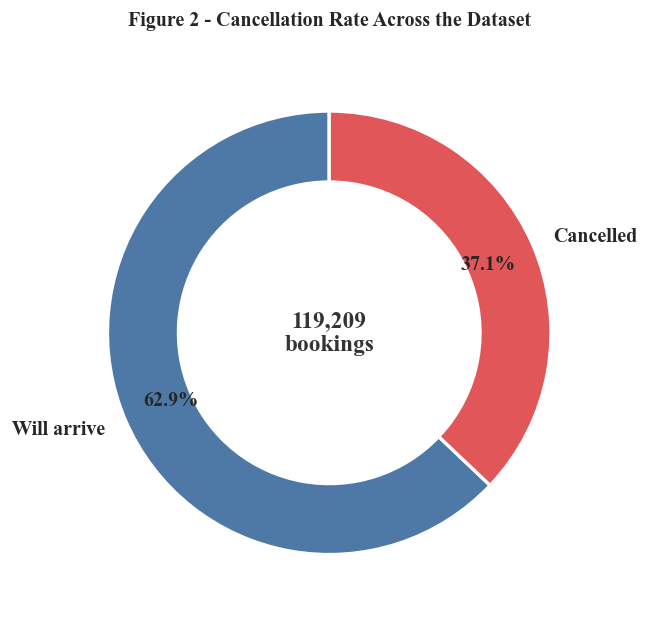

44,199 of 119,209 bookings cancelled (37.1%) - class is imbalanced but not extreme.


In [7]:
# Cancellation rate at a glance - donut chart with absolute counts in the centre.
counts = df[TARGET_COL].value_counts().reindex([0, 1], fill_value=0)
labels = ["Will arrive", "Cancelled"]
colors = ["#4e79a7", "#e15759"]
sizes = [int(counts.get(0, 0)), int(counts.get(1, 0))]
total = sum(sizes)

fig, ax = plt.subplots(figsize=(7.5, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.32, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=12, fontweight="bold"),
)
ax.text(0, 0, f"{total:,}\nbookings", ha="center", va="center",
        fontsize=14, fontweight="bold", color="#333333")
ax.set_title("Figure 2 - Cancellation Rate Across the Dataset",
             fontsize=12, fontweight="bold", pad=18)
save_thesis_figure(fig, 2, "cancellation_rate_donut", FIG_DIR)
plt.show()

cancelled = sizes[1]
print(f"{cancelled:,} of {total:,} bookings cancelled "
      f"({cancelled / total * 100:.1f}%) - class is imbalanced but not extreme.")


**Key Takeaway — Cancellation Rate**: About **37% of bookings are cancelled** — roughly one in three. This is important because a naive model that always predicts "not cancelled" would still be 63% accurate, which sounds good but is actually useless. That's why we use a smarter metric called **PR-AUC** (Precision-Recall Area Under Curve) that specifically measures how well we detect the cancellations.

## 1.4 Does the Cancellation Rate Change Over Time?

The chart below shows the monthly cancellation rate (blue line with grey confidence band) and booking volume (orange bars). Vertical dashed lines mark where we split the data for training vs. testing.

This uses the pre-built `plot_monthly_trend()` from `notebook_utils`.

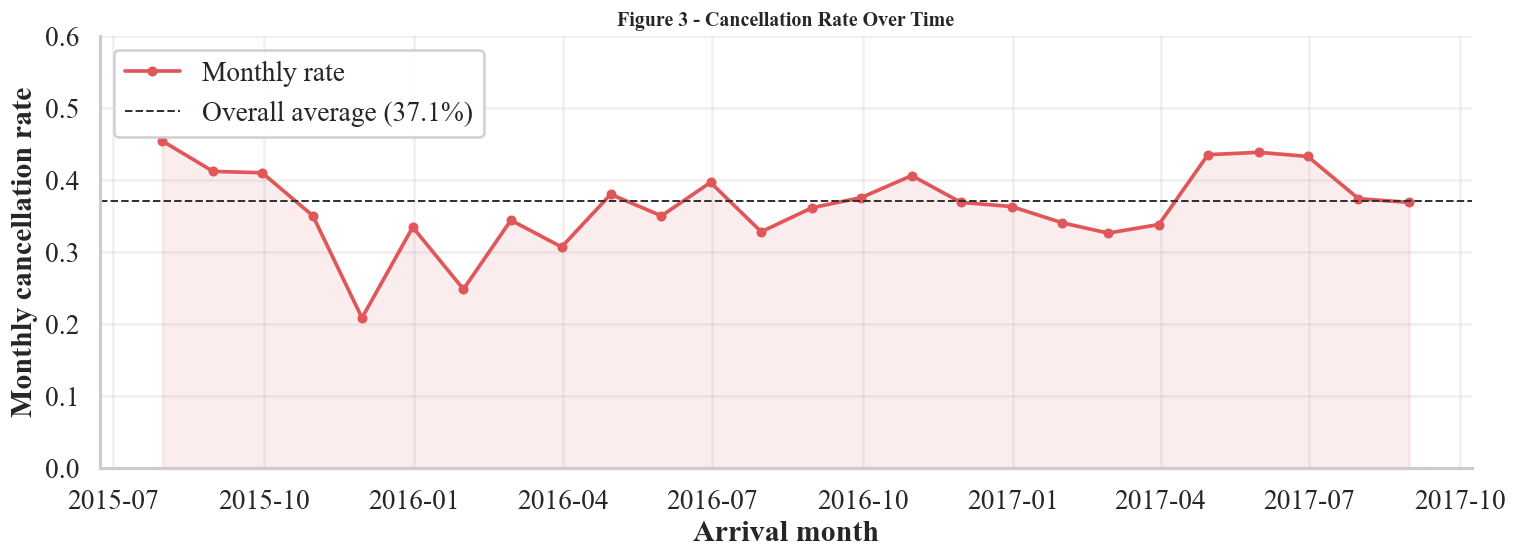

Coverage: 26 months from 2015-07-31 to 2017-08-31
Range:    20.8% - 45.4% (mean 37.1%)


In [8]:
# Monthly cancellation rate - justifies the chronological train/val/test split.
from src.features.build import add_arrival_date

df_dated = df.copy()
df_dated["_arrival_date"] = add_arrival_date(df_dated)
monthly = (
    df_dated.set_index("_arrival_date")
    .groupby(pd.Grouper(freq="ME"))[TARGET_COL]
    .agg(["mean", "count"])
    .rename(columns={"mean": "cancel_rate", "count": "n"})
    .dropna()
)
overall_rate = df[TARGET_COL].mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly["cancel_rate"], color="#e15759", linewidth=2.2,
        marker="o", markersize=5, label="Monthly rate")
ax.fill_between(monthly.index, 0, monthly["cancel_rate"], color="#e15759", alpha=0.10)
ax.axhline(overall_rate, color="#333333", linestyle="--", linewidth=1.2,
           label=f"Overall average ({overall_rate:.1%})")
ax.set_ylim(0, max(0.6, monthly["cancel_rate"].max() * 1.12))
ax.set_ylabel("Monthly cancellation rate")
ax.set_xlabel("Arrival month")
ax.set_title("Figure 3 - Cancellation Rate Over Time",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper left", framealpha=0.92)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_thesis_figure(fig, 3, "monthly_cancel_rate_trend", FIG_DIR)
plt.show()

print(f"Coverage: {len(monthly)} months from {monthly.index.min().date()} "
      f"to {monthly.index.max().date()}")
print(f"Range:    {monthly['cancel_rate'].min():.1%} - "
      f"{monthly['cancel_rate'].max():.1%} (mean {overall_rate:.1%})")


**Key Takeaway — Time Trends**: The cancellation rate isn't flat — it trends upward in mid-2016 to early 2017. This means we can't just randomly shuffle the data for testing; we must split it **chronologically** (older data for training, newer data for testing) so the model is always evaluated on "future" bookings it hasn't seen. The vertical dashed lines show exactly where these splits occur.

## 1.5 What Patterns Do We See in Booking Numbers?

The histograms below show how key numerical features are distributed, split by cancellation status (blue = kept, red = cancelled). Where the red and blue shapes look very different, that feature is likely useful for prediction.

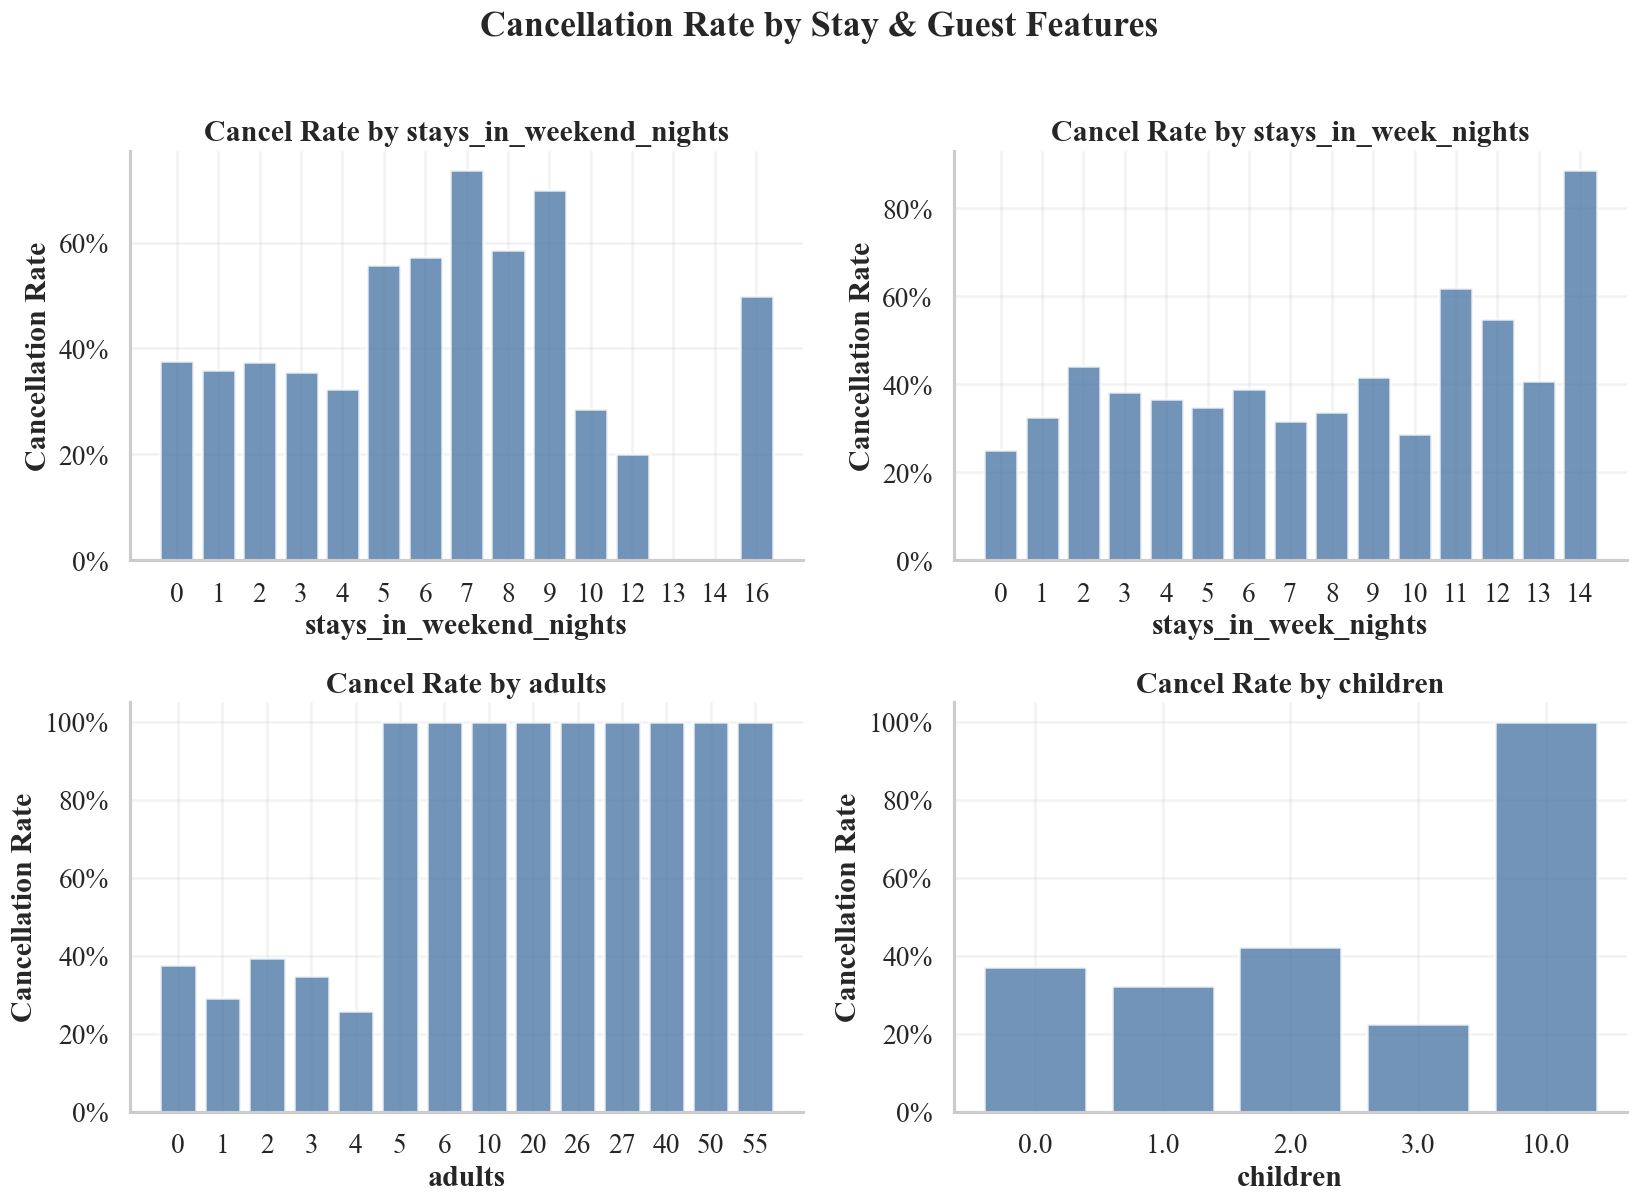

In [9]:
stay_features = ["stays_in_weekend_nights", "stays_in_week_nights", "adults", "children"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), stay_features):
    cancel_rate = df.groupby(col)[TARGET_COL].mean()
    counts = df[col].value_counts().sort_index()
    top_values = counts.head(15).index
    cancel_rate = cancel_rate.loc[cancel_rate.index.isin(top_values)]
    ax.bar(cancel_rate.index.astype(str), cancel_rate.values, color="#4e79a7", alpha=0.8)
    ax.set_title(f"Cancel Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Cancellation Rate")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

fig.suptitle("Cancellation Rate by Stay & Guest Features", fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

**Key Takeaway — Stay & Guest Features**: Weekend and weeknight stays show relatively flat cancellation rates, meaning the length of stay alone isn't a strong predictor. The number of adults and children matters more at extremes — bookings with unusual guest counts (e.g., 0 children vs. 3+) show different patterns.

### 1.5b How Are Lead Time, Daily Rate, and Stay Length Distributed?

The three histograms below show the **shape** of the most decision-relevant booking-time features. Each bar is the count of bookings; the **vertical dashed lines** mark the median (orange) and the 95th percentile (red).

What to look for: most bookings cluster near zero with a long thin tail extending to the right - that is a **right-skewed** distribution, common in real-world booking data. The 95th-percentile line shows where the bulk ends and the tail begins; data points beyond it are unusual but legitimate (luxury suites, long-haul early bookings, extended stays).

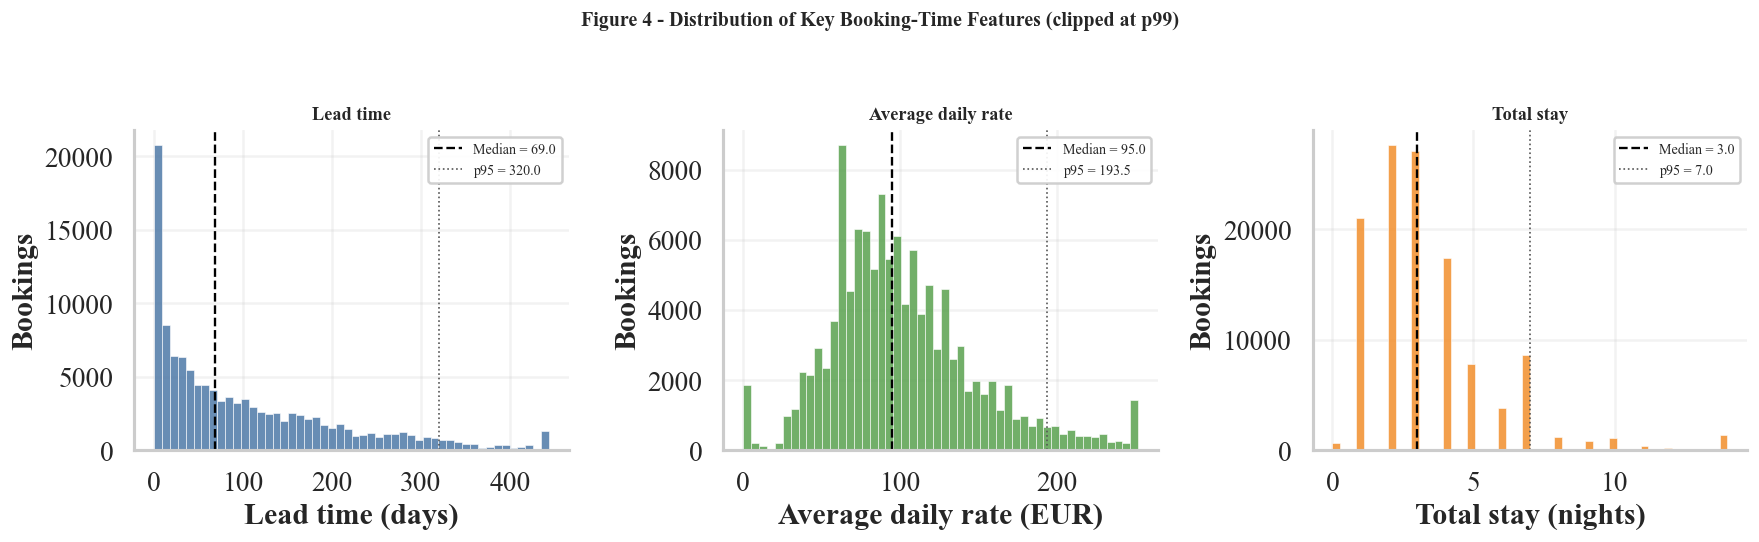

In [10]:
# Distribution shape of three booking-time features that drive feature engineering.
df_lk = df.copy()
df_lk["total_stay"] = df_lk["stays_in_weekend_nights"] + df_lk["stays_in_week_nights"]

specs = [
    ("lead_time", "Lead time (days)",      "#4e79a7"),
    ("adr",       "Average daily rate (EUR)", "#59a14f"),
    ("total_stay","Total stay (nights)",     "#f28e2b"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (col, label, color) in zip(axes, specs):
    vals = df_lk[col].dropna()
    p99 = vals.quantile(0.99)
    p95 = vals.quantile(0.95)
    median = vals.median()
    ax.hist(vals.clip(upper=p99), bins=50, color=color, alpha=0.85,
            edgecolor="white", linewidth=0.4)
    ax.axvline(median, color="black", linewidth=1.4, linestyle="--",
               label=f"Median = {median:.1f}")
    ax.axvline(p95, color="#555555", linewidth=1.0, linestyle=":",
               label=f"p95 = {p95:.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Bookings")
    ax.set_title(label.split("(")[0].strip(), fontsize=11, fontweight="bold")
    ax.legend(loc="upper right", fontsize=8.5, framealpha=0.92)
    ax.grid(True, alpha=0.25)
fig.suptitle("Figure 4 - Distribution of Key Booking-Time Features (clipped at p99)",
             fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
save_thesis_figure(fig, 4, "feature_distributions", FIG_DIR)
plt.show()


**Key Takeaway — Numerical Features**: 
- **Lead time** is the biggest differentiator: cancelled bookings are typically booked much further in advance (~130 days vs. ~45 days). People who plan far ahead are more likely to change their minds.
- **Room rate (ADR)**: Higher-priced bookings cancel slightly more often, suggesting price sensitivity.
- **Special requests**: Guests who make zero special requests cancel more often — they're less committed to the specific stay.
- **Previous cancellations**: Guests who cancelled before are much more likely to cancel again — past behaviour predicts future behaviour.

**What to look for in this chart:** The boxplot below shows the **raw** ADR distribution before cleaning. Each blue dot beyond the whiskers is an outlier. Two red dashed lines mark the cleaning cut points (ADR = 0 and ADR = 1000). Bookings to the left of the left line are negative rates (data-entry errors); bookings to the right of the right line are unrealistic luxury prices (likely currency-conversion bugs). Everything between the lines is kept.


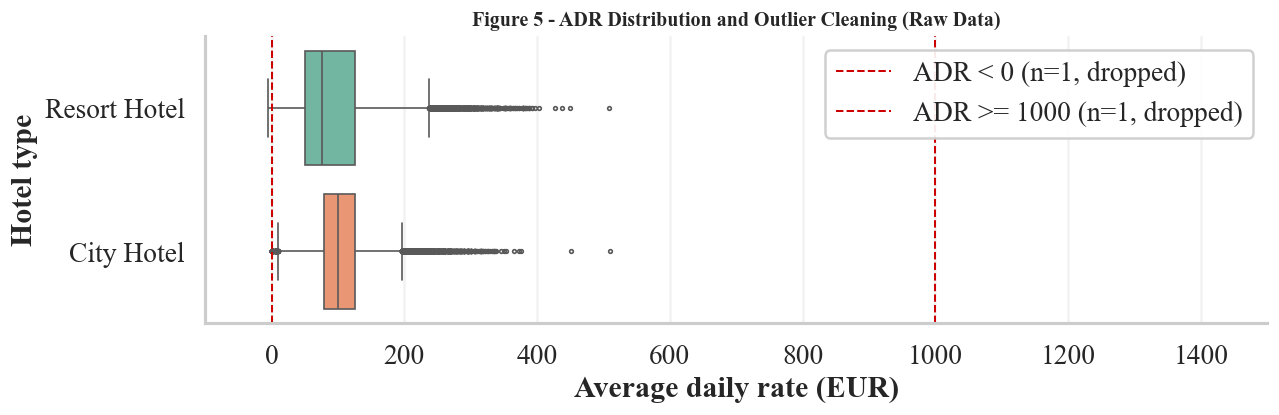

Raw rows:        119,390
Dropped (ADR):   2
After cleaning:  119,209 rows kept.


In [11]:
# Visual justification of the ADR cleaning rules - show outliers in raw data,
# the cut points (red dashed lines), and the resulting kept rows.
raw_adr_below_zero = (df_raw["adr"] < 0).sum()
raw_adr_above_cap  = (df_raw["adr"] >= 1000).sum()
kept_rows = df.shape[0]

fig, ax = plt.subplots(figsize=(11, 3.8))
sns.boxplot(
    data=df_raw, x="adr", y="hotel",
    hue="hotel", legend=False,
    ax=ax, palette="Set2", showfliers=True, fliersize=2.2,
)
ax.axvline(0,     color="#cc0000", linestyle="--", linewidth=1.2,
           label=f"ADR < 0 (n={raw_adr_below_zero}, dropped)")
ax.axvline(1000,  color="#cc0000", linestyle="--", linewidth=1.2,
           label=f"ADR >= 1000 (n={raw_adr_above_cap}, dropped)")
ax.set_xlim(-100, 1500)
ax.set_xlabel("Average daily rate (EUR)")
ax.set_ylabel("Hotel type")
ax.set_title("Figure 5 - ADR Distribution and Outlier Cleaning (Raw Data)",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper right", framealpha=0.92)
ax.grid(True, axis="x", alpha=0.25)
fig.tight_layout()
save_thesis_figure(fig, 5, "adr_outliers_boxplot", FIG_DIR)
plt.show()

print(f"Raw rows:        {df_raw.shape[0]:,}")
print(f"Dropped (ADR):   {raw_adr_below_zero + raw_adr_above_cap}")
print(f"After cleaning:  {kept_rows:,} rows kept.")


**Key Takeaway — Outlier Cleaning:** The ADR cleaning rules are calibrated to *actual* outliers, not arbitrary thresholds. The handful of rows with `adr < 0` or `adr >= 1000` represent data-entry errors (a free room or a typo) rather than legitimate rates the model should learn from. Dropping them removes < 0.1% of rows.

## 1.6 Which Booking Categories Have the Highest Cancellation Rates?

The horizontal bar charts below show cancellation rates broken down by hotel type, market segment, deposit type, and customer type. Longer bars = higher cancellation rates. The numbers in parentheses show how many bookings fall into each category.

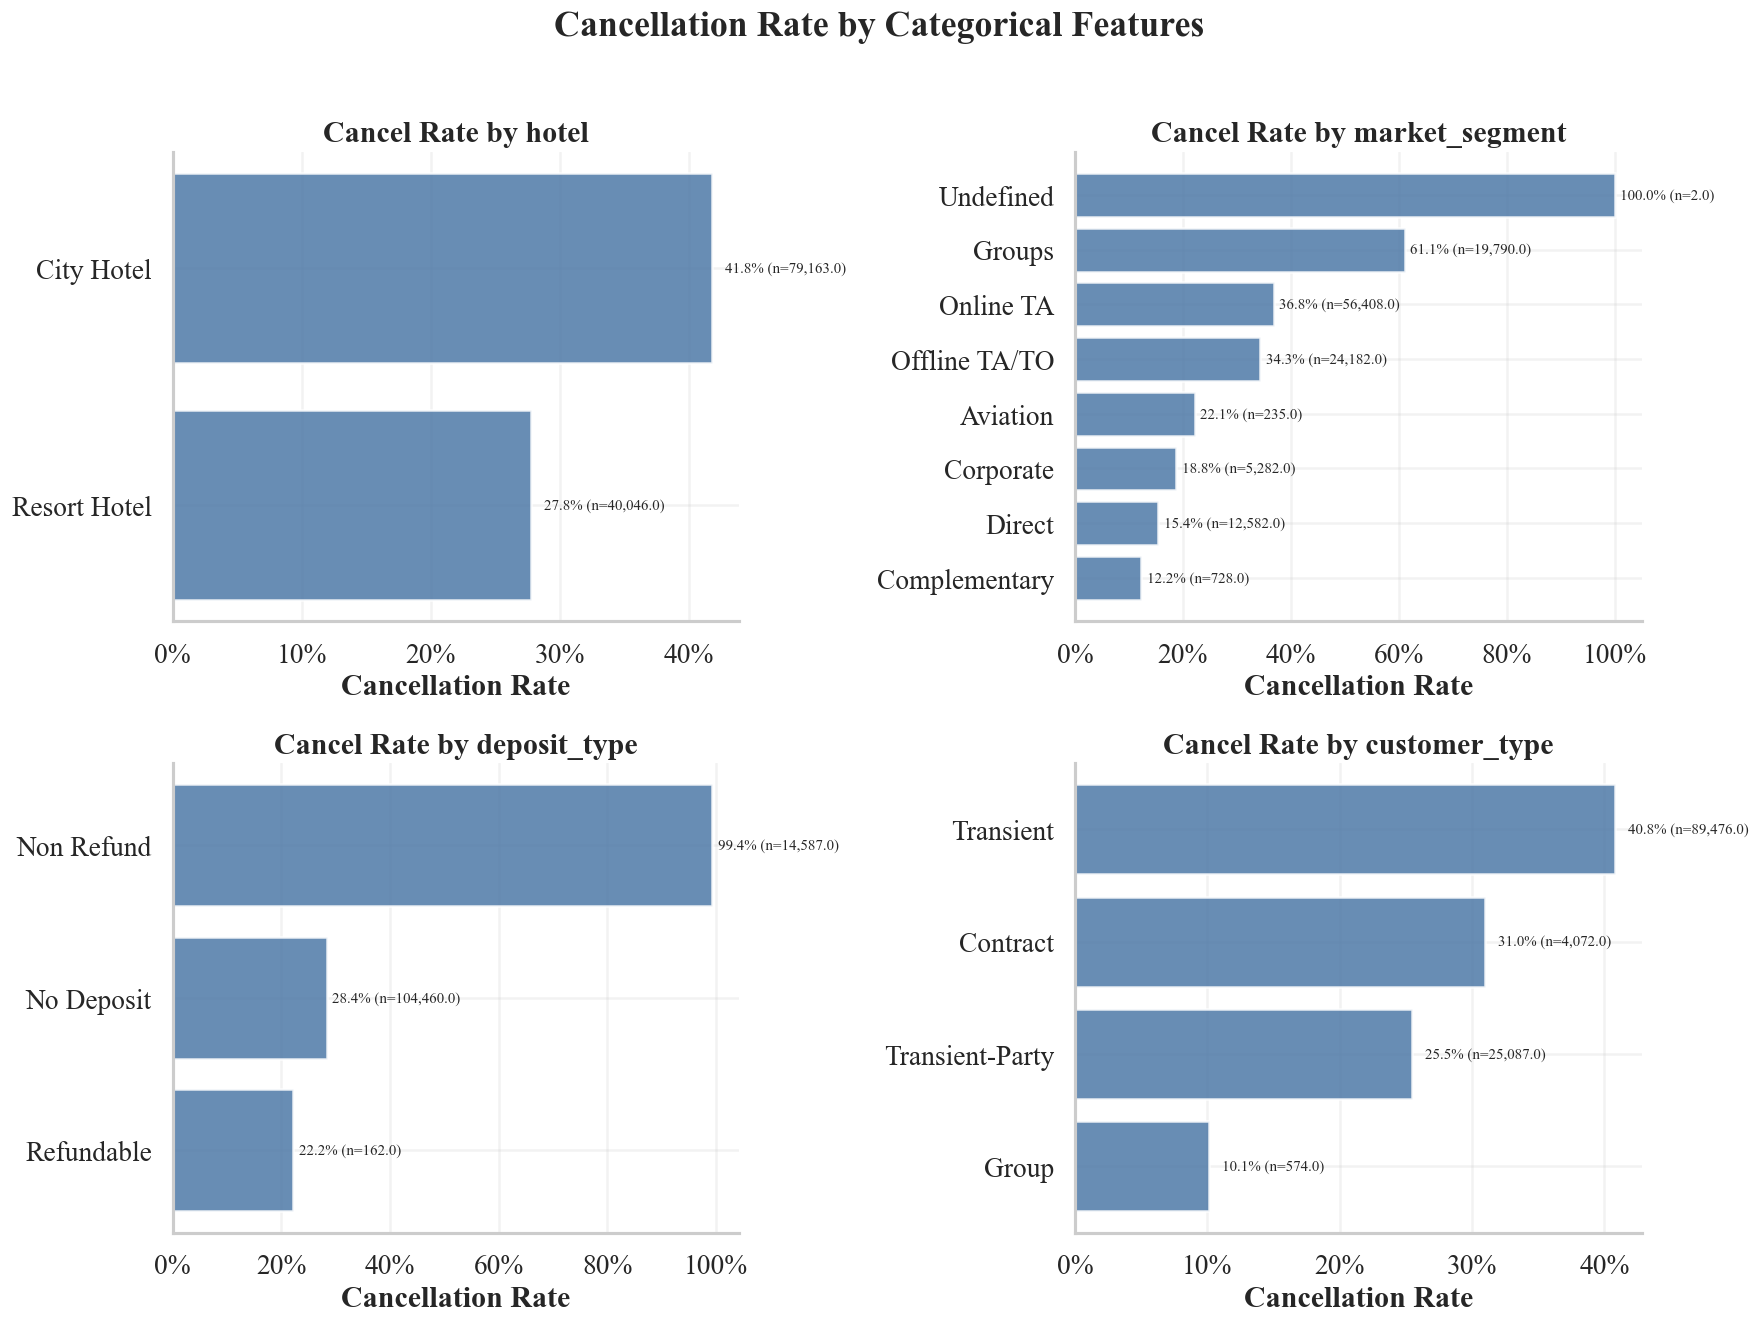

In [12]:
cat_features = ["hotel", "market_segment", "deposit_type", "customer_type"]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for ax, col in zip(axes.ravel(), cat_features):
    summary = (
        df.groupby(col)[TARGET_COL]
        .agg(["mean", "count"])
        .rename(columns={"mean": "cancel_rate", "count": "n"})
        .sort_values("cancel_rate", ascending=True)
    )
    bars = ax.barh(summary.index.astype(str), summary["cancel_rate"], color="#4e79a7", alpha=0.85)
    for bar, (_, row) in zip(bars, summary.iterrows()):
        ax.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{row['cancel_rate']:.1%} (n={row['n']:,})",
            va="center",
            fontsize=9,
        )
    ax.set_title(f"Cancel Rate by {col}")
    ax.set_xlabel("Cancellation Rate")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

fig.suptitle("Cancellation Rate by Categorical Features", fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

**Key Takeaway — Categorical Features**:
- **City hotels** cancel more than resort hotels — city travellers may have more flexible plans.
- **Online Travel Agencies (OTAs)** and **Groups** have the highest cancellation rates among booking channels.
- **Transient** (individual, non-contract) customers cancel most often.
- **Non-Refundable deposits** show ~99% cancellation, but this is a **data recording convention**, not a real prediction signal. When a non-refundable booking is cancelled, the hotel keeps the money but still records the room as released. This is why we carefully exclude post-booking columns from the model.

### 1.6b Why Does `deposit_type` Cancel So Differently? - A Deeper Look

Among the four categorical features above, `deposit_type` deserves special attention because its three categories behave **radically differently**. Hotels offer three payment models at the time of booking:

| Type | Hotel-industry meaning | Money charged at booking |
|---|---|---|
| **No Deposit** | Guest reserves the room and pays at check-in | EUR 0 |
| **Non Refund** | Guest pays the full stay amount immediately; no refund if cancelled | Full price |
| **Refundable** | Guest pays a deposit (often the first night); refundable before deadline | Partial |

The table below shows how each type actually behaves in this dataset - the result is one of the most striking single findings in the EDA.


In [13]:
# Empirical cancellation behaviour broken down by deposit_type, with context
# columns (avg lead time, avg ADR) that help explain WHY the rates differ.
deposit_breakdown = (
    df.groupby("deposit_type")
      .agg(
          bookings=("is_canceled", "size"),
          cancelled=("is_canceled", "sum"),
          cancel_rate=("is_canceled", "mean"),
          avg_lead_time_days=("lead_time", "mean"),
          avg_adr=("adr", "mean"),
      )
      .round(3)
)
deposit_breakdown["share_of_total"] = (
    deposit_breakdown["bookings"] / deposit_breakdown["bookings"].sum()
)
deposit_breakdown = deposit_breakdown[
    ["bookings", "share_of_total", "cancelled", "cancel_rate",
     "avg_lead_time_days", "avg_adr"]
]


def _highlight_non_refund(row):
    is_nr = row.name == "Non Refund"
    return [
        "background-color: #f8d7da; font-weight: bold" if is_nr else ""
        for _ in row
    ]


display(
    deposit_breakdown.style
    .apply(_highlight_non_refund, axis=1)
    .format({
        "bookings": "{:,}",
        "share_of_total": "{:.1%}",
        "cancelled": "{:,}",
        "cancel_rate": "{:.1%}",
        "avg_lead_time_days": "{:.0f}",
        "avg_adr": "{:.2f}",
    })
    .set_caption("Table 1.6 - Cancellation Behaviour by Deposit Type")
)

overall = df["is_canceled"].mean()
nr_rate = deposit_breakdown.loc["Non Refund", "cancel_rate"]
print(f"\nOverall dataset cancel rate: {overall:.1%}")
print(f"Non Refund cancel rate:      {nr_rate:.1%}  <- striking outlier")


,bookings,share_of_total,cancelled,cancel_rate,avg_lead_time_days,avg_adr
deposit_type,,,,,,
No Deposit,"104,460",87.6%,"29,669",28.4%,89,103.69
Non Refund,"14,587",12.2%,"14,494",99.4%,213,89.96
Refundable,162,0.1%,36,22.2%,152,76.21



Overall dataset cancel rate: 37.1%
Non Refund cancel rate:      99.4%  <- striking outlier


**Key Takeaway - Non Refund Is a Near-Deterministic Predictor:**

Three observations stand out:

1. **Non Refund bookings cancel 99.4% of the time** - even though the guest has already paid the full amount up front and would lose all of it. This isn't because guests routinely change their minds; the dataset codes **no-shows as cancellations**, and the average lead time for Non Refund (213 days) is so long that many guests forfeit the money rather than rebook a stay nearly a year away.

2. **No Deposit bookings (87.6% of the dataset) cancel below average** (28.4% vs the overall 37.1%). People who pay nothing up front are also typically booking shorter-lead-time stays where plans are firmer.

3. **Refundable bookings have the lowest cancel rate** (22.2%) - paying even a small deposit signals more commitment - but with only 162 examples in the dataset, this segment is too small to drive model decisions.

**Implication for the model.** Because Non Refund is a near-deterministic rule, the model will lean heavily on this feature. In Notebook 05, `deposit_type_Non Refund` consistently ranks in the top 5 SHAP contributors. A panelist might ask: *"Is the model genuinely predictive, or is it just memorising Non Refund = cancelled?"* The honest answer (confirmed in Notebook 03) is that the model retains strong predictive performance on the No Deposit subset alone, so the signal is real beyond this single rule - but it's worth declaring this finding explicitly rather than letting it hide inside the SHAP plot.


### 1.6c Why Does `market_segment` Vary So Much? - A Deeper Look

`market_segment` describes **how the booking reached the hotel** - the sales channel. Industry-wide, each channel has a distinct guest psychology, payment structure, and cancellation behaviour. The eight categories in this dataset are:

| Segment | What it means (hotel-industry term) | Who's booking |
|---|---|---|
| **Direct** | Guest contacts the hotel directly (phone, hotel website, walk-in) | High-commitment leisure travellers, repeat guests |
| **Online TA** | Booking.com, Expedia, Agoda, Hotels.com, similar online travel agencies | Largest channel - price-shoppers comparing many properties |
| **Offline TA/TO** | Brick-and-mortar travel agent or tour operator (often a package-holiday component) | Older demographic, often pre-paid packages |
| **Groups** | Conferences, weddings, sports teams, tour buses, group bookings via a sales team | Group leader books on behalf of many, often well in advance |
| **Corporate** | Negotiated corporate-rate contracts (business travel) | Regular business clients, expense-account stays |
| **Complementary** | Free rooms (loyalty redemption, VIP comp, promotional gift) | High-commitment guests - they're already invested in the relationship |
| **Aviation** | Airline crew layovers (contractual, ~always overnight) | Pilots and cabin crew on layover; near-100% show rate |
| **Undefined** | Data-quality artefact (~2 rows) - safely ignored | n/a |

The table below shows the actual numbers from this dataset - cancellation rates span **5x** across segments, the widest spread of any categorical feature.


,bookings,share_of_total,cancelled,cancel_rate,avg_lead_time_days,avg_adr
market_segment,,,,,,
Complementary,728,0.6%,89,12.2%,14,2.95
Direct,"12,582",10.6%,"1,934",15.4%,50,115.63
Corporate,"5,282",4.4%,991,18.8%,22,69.53
Aviation,235,0.2%,52,22.1%,4,100.99
Offline TA/TO,"24,182",20.3%,"8,302",34.3%,135,87.48
Online TA,"56,408",47.3%,"20,735",36.8%,83,117.32
Groups,"19,790",16.6%,"12,094",61.1%,187,79.56



Overall dataset cancel rate: 37.1%
Spread across segments: 12.2% (Complementary) -> 61.1% (Groups) - 4.0x ratio


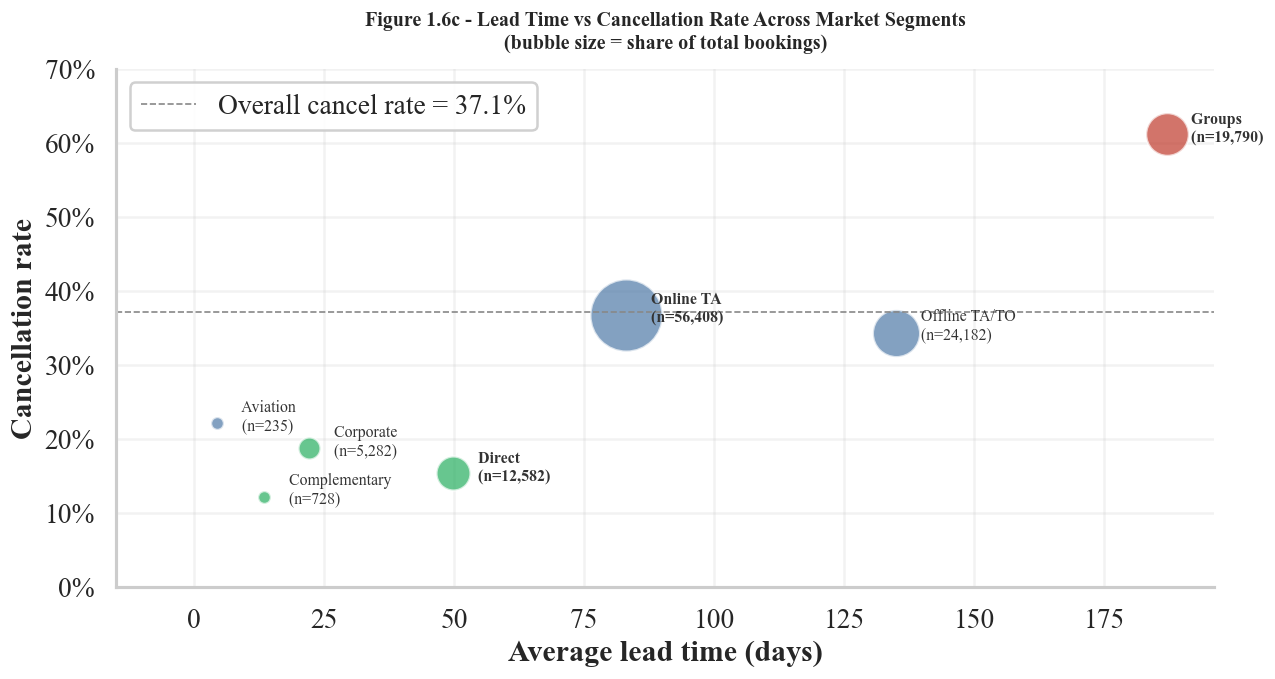

In [14]:
# Empirical cancellation behaviour broken down by market_segment, with context
# columns (avg lead time, avg ADR) that help explain WHY the rates differ.
segment_breakdown = (
    df.groupby("market_segment")
      .agg(
          bookings=("is_canceled", "size"),
          cancelled=("is_canceled", "sum"),
          cancel_rate=("is_canceled", "mean"),
          avg_lead_time_days=("lead_time", "mean"),
          avg_adr=("adr", "mean"),
      )
      .sort_values("cancel_rate", ascending=True)
)
segment_breakdown["share_of_total"] = (
    segment_breakdown["bookings"] / segment_breakdown["bookings"].sum()
)
# Drop the noise row "Undefined" (only 2 bookings) so the visual story stays clean
segment_breakdown = segment_breakdown[segment_breakdown["bookings"] >= 50]
segment_breakdown = segment_breakdown[
    ["bookings", "share_of_total", "cancelled", "cancel_rate",
     "avg_lead_time_days", "avg_adr"]
]


def _highlight_extremes(row):
    name = row.name
    if name == "Groups":
        return ["background-color: #f8d7da; font-weight: bold"] * len(row)
    if name in ("Direct", "Complementary"):
        return ["background-color: #d4edda; font-weight: bold"] * len(row)
    return [""] * len(row)


display(
    segment_breakdown.style
    .apply(_highlight_extremes, axis=1)
    .format({
        "bookings": "{:,}",
        "share_of_total": "{:.1%}",
        "cancelled": "{:,}",
        "cancel_rate": "{:.1%}",
        "avg_lead_time_days": "{:.0f}",
        "avg_adr": "{:.2f}",
    })
    .set_caption("Table 1.6c - Cancellation Behaviour by Market Segment "
                 "(green = high-commitment channels, red = high-risk channel)")
)

overall = df["is_canceled"].mean()
groups_rate = float(segment_breakdown.loc["Groups", "cancel_rate"])
direct_rate = float(segment_breakdown.loc["Direct", "cancel_rate"])
print(f"\nOverall dataset cancel rate: {overall:.1%}")
print(f"Spread across segments: "
      f"{segment_breakdown['cancel_rate'].min():.1%} (Complementary) -> "
      f"{segment_breakdown['cancel_rate'].max():.1%} (Groups) - {groups_rate/direct_rate:.1f}x ratio")

# Companion scatter: lead time vs cancel rate, sized by booking volume.
# This visualises the strongest pattern in the table - long lead times correlate
# with high cancellation - in a way the table alone cannot.
fig, ax = plt.subplots(figsize=(11, 6))
for seg, row in segment_breakdown.iterrows():
    n = int(row["bookings"])
    lt = float(row["avg_lead_time_days"])
    cr = float(row["cancel_rate"])
    # Bubble size proportional to share of total (scaled for visibility)
    bubble = max(60, n / 30)
    if seg == "Groups":
        col = "#c0392b"
    elif seg in ("Direct", "Complementary", "Corporate"):
        col = "#27ae60"
    else:
        col = "#4e79a7"
    ax.scatter(lt, cr, s=bubble, color=col, alpha=0.7, edgecolor="white", linewidth=1.4)
    # Label slightly offset to avoid clipping the bubble
    ax.annotate(
        f"  {seg}\n  (n={n:,})",
        xy=(lt, cr),
        xytext=(10, -4),
        textcoords="offset points",
        fontsize=9.5,
        fontweight="bold" if seg in ("Groups", "Direct", "Online TA") else "normal",
        color="#333",
    )

ax.axhline(overall, color="#888", linestyle="--", linewidth=1.0,
           label=f"Overall cancel rate = {overall:.1%}")
ax.set_xlabel("Average lead time (days)")
ax.set_ylabel("Cancellation rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title(
    "Figure 1.6c - Lead Time vs Cancellation Rate Across Market Segments\n"
    "(bubble size = share of total bookings)",
    fontsize=12, fontweight="bold", pad=12,
)
ax.legend(loc="upper left", framealpha=0.92)
ax.grid(True, alpha=0.25)
ax.set_xlim(left=-15)
ax.set_ylim(0, max(0.7, segment_breakdown["cancel_rate"].max() * 1.12))
fig.tight_layout()
save_thesis_figure(fig, "1.6c", "market_segment_lead_time_cancel", FIG_DIR)
plt.show()


**Key Takeaway - Sales Channel Is a Booking's First Risk Signal:**

Three patterns stand out from the table and scatter plot:

1. **Groups cancel 4x more than Direct bookings (61% vs 15%).** Group bookings (conferences, weddings, tour groups) are made by a coordinator on behalf of many - the coordinator has no personal stake in any single room. Direct bookers (people who phoned the hotel or used its own website) self-selected for high commitment.

2. **Lead time and cancellation move together across channels.** Groups (187-day average lead time) and Offline TA (135 days) book far in advance and cancel often. Direct (50 days), Corporate (22 days), and Aviation (4 days) book close to the stay date and rarely cancel. This is intuitive: more time before the stay = more opportunities for plans to change.

3. **Online TA is the dominant channel (47% of all bookings).** This single segment is roughly equal to Direct + Offline TA + Corporate combined. Its 36.8% cancellation rate is close to the dataset average - online travel agencies are the *baseline* in this dataset, not an outlier.

**Implication for the model.** `market_segment` is the model's #11 most important feature (split-count), but it's a strong *interaction partner*: combine `market_segment=Groups` with `lead_time > 150` and the predicted cancellation probability jumps sharply because both signals point the same direction. The model is also robust to the rare segments - Aviation (235 bookings) and Complementary (728) appear infrequently enough that the OneHotEncoder's `min_freq=0.01` keeps them in the learned vocabulary, so a UI prediction for either channel still gets a properly differentiated answer.

**Defense panelist question to expect:** *"If Groups always cancel, shouldn't we just refuse group bookings?"* The answer is no - 39% of group bookings still show up, and the model's value is in identifying *which* group bookings are likely to convert (short lead time, repeat client, paid deposit) versus which are likely to fall through. That's a more profitable strategy than refusing the channel entirely.


## 1.7 Which Factors Are Most Connected to Cancellations?

The bar chart below ranks the top 10 numeric features by how strongly they correlate with cancellations. Red bars = positive correlation (higher value → more cancellations), blue bars = negative correlation (higher value → fewer cancellations).

We also list the **leakage columns** — data that would not be available at booking time and must be excluded from the model.

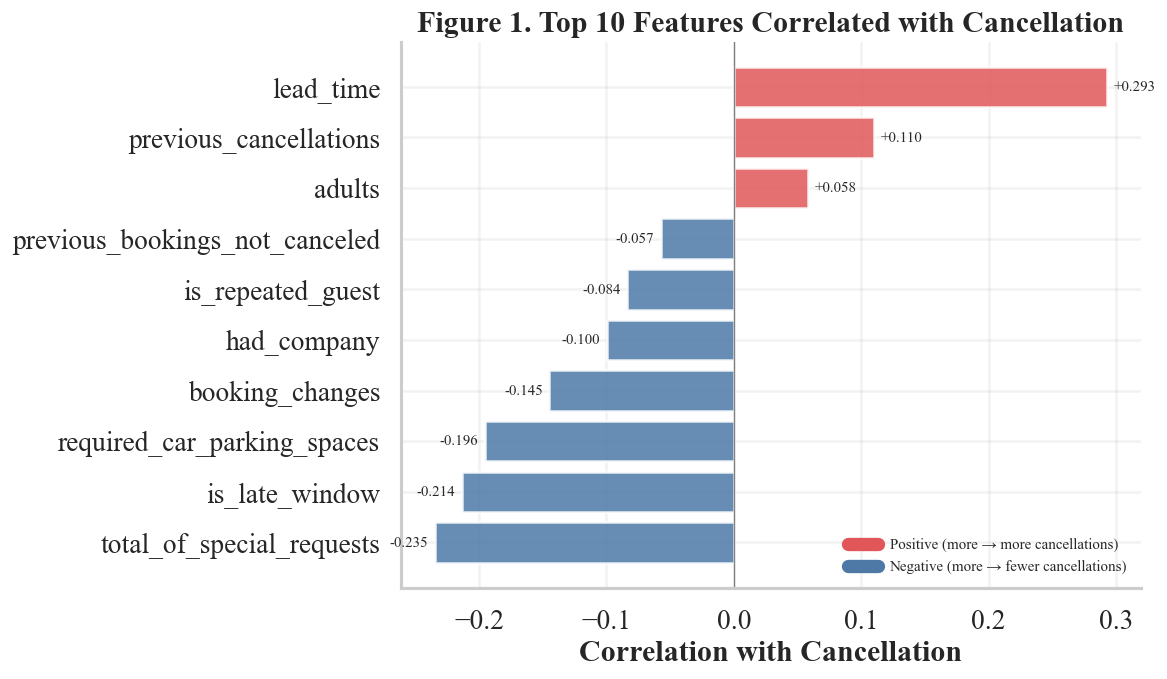

In [15]:
from src.eval.notebook_utils import plot_top_correlations_bar

plot_top_correlations_bar(df, TARGET_COL, FIG_DIR, fig_no=1, top_k=10)
plt.show()

In [16]:
leakage_in_data = [c for c in LEAKAGE_COLS if c in df_raw.columns]
leakage_df = pd.DataFrame({
    "column": leakage_in_data,
    "reason": [
        "Directly derived from outcome" if c == "reservation_status" else
        "Known only after check-in/outcome" if c == "reservation_status_date" else
        "Assigned at check-in, not booking time" if c == "assigned_room_type" else
        "Accumulated post-booking" if c == "booking_changes" else
        "Post-booking operational metric"
        for c in leakage_in_data
    ],
})
display(
    leakage_df.style
    .set_caption("Leakage Columns Excluded from Modeling")
    .hide(axis="index")
)

column,reason
reservation_status,Directly derived from outcome
reservation_status_date,Known only after check-in/outcome
assigned_room_type,"Assigned at check-in, not booking time"
booking_changes,Accumulated post-booking
days_in_waiting_list,Post-booking operational metric


**Key Takeaway — Leakage Prevention**: These columns are excluded because they contain information that would **not be available at booking time** (the moment we need to make our prediction). For example, `reservation_status` literally tells you whether the booking was cancelled — using it would be like looking at the answer sheet during an exam. Including these columns would make the model look unrealistically perfect, but it would be useless in practice.

## 1.8 Are Categorical Features Statistically Associated with Cancellations?

The correlations above only work for numerical features. For categorical features (hotel type, market segment, etc.), we use the **chi-squared test** — a standard statistical method that checks whether a feature is related to cancellations.

We tested every categorical booking-time feature and all are statistically significant (p < 0.05). **Cramer's V** measures the strength of the relationship: 0 = no relationship, 1 = perfect relationship.

In [17]:
from src.eval.notebook_utils import chi_squared_independence

# Test categorical booking-time features against cancellation status
# (exclude leakage columns — they won't be available at prediction time)
cat_cols = [
    c for c in df.select_dtypes(include="object").columns
    if c != TARGET_COL and c not in LEAKAGE_COLS
]
chi2_results = chi_squared_independence(df, cat_cols)

display(
    chi2_results.style
    .format({"p-value": "{:.2e}", "Cramér's V": "{:.4f}"})
    .set_caption("Chi-Squared Independence Tests: Categorical Features vs. Cancellation")
    .hide(axis="index")
)

Feature,Chi2 Statistic,p-value,Degrees of Freedom,Cramér's V,Significant?
deposit_type,27641.060000,0.00e+00,2,0.4815,Yes
country,15619.810000,0.00e+00,177,0.3620,Yes
market_segment,8499.730000,0.00e+00,7,0.2670,Yes
distribution_channel,3741.320000,0.00e+00,4,0.1772,Yes
hotel,2239.270000,0.00e+00,1,0.1371,Yes
customer_type,2224.650000,0.00e+00,3,0.1366,Yes
reserved_room_type,631.320000,4.31e-131,8,0.0728,Yes
arrival_date_month,582.080000,9.53e-118,11,0.0699,Yes
meal,305.030000,8.89e-65,4,0.0506,Yes


**What to look for in this chart:** Each bar shows the *strength* of association between a categorical feature and cancellation. The two grey dashed lines mark the convention thresholds: bars to the right of the first line (0.10) indicate a noticeable effect; bars beyond the second line (0.20) indicate a strong effect. Statistical significance (every p-value < 0.001) only tells us *whether* a relationship exists; Cramér's V tells us *how big* it is.


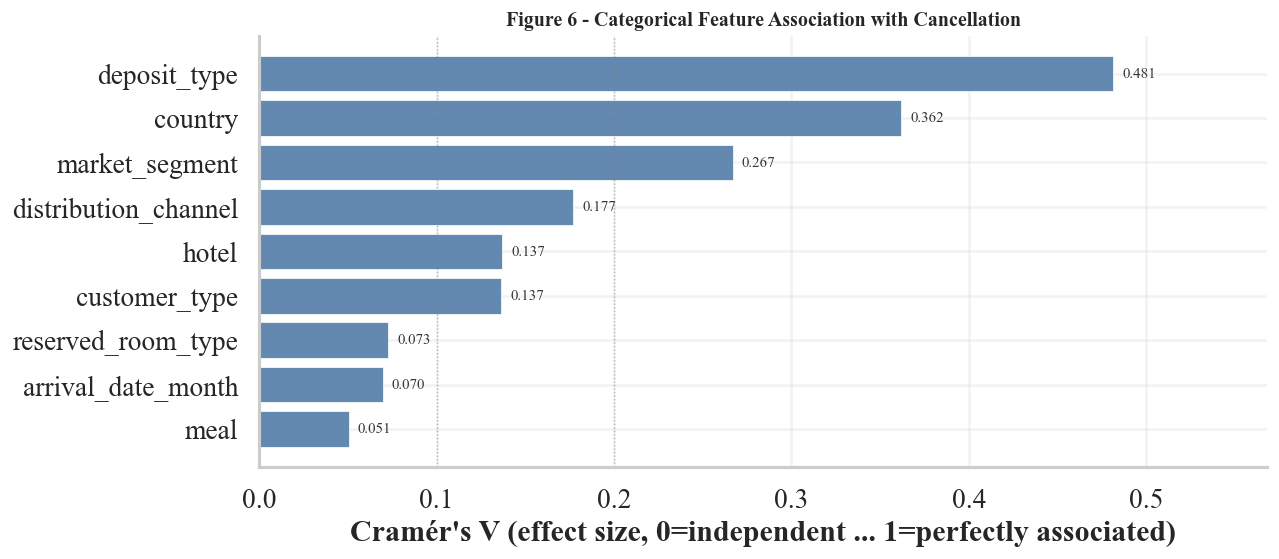

Top 3 categorical features by association strength:
  deposit_type              V = 0.481
  country                   V = 0.362
  market_segment            V = 0.267


In [18]:
# Cramér's V translates chi-squared p-values into a practical effect size
# (0 = independent, 1 = perfectly associated).  Lets us rank categorical
# features by HOW STRONGLY they relate to cancellation, not just whether.
sorted_results = chi2_results.sort_values("Cramér's V", ascending=True)

fig, ax = plt.subplots(figsize=(11, max(5, len(sorted_results) * 0.42)))
bars = ax.barh(
    sorted_results["Feature"], sorted_results["Cramér's V"],
    color="#4e79a7", alpha=0.88, edgecolor="white", linewidth=0.5,
)
for bar, val in zip(bars, sorted_results["Cramér's V"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left", fontsize=9, color="#333")

ax.axvline(0.10, color="#888888", linewidth=0.8, linestyle=":", alpha=0.6)
ax.axvline(0.20, color="#888888", linewidth=0.8, linestyle=":", alpha=0.6)

ax.set_xlabel("Cramér's V (effect size, 0=independent ... 1=perfectly associated)")
ax.set_title("Figure 6 - Categorical Feature Association with Cancellation",
             fontsize=12, fontweight="bold")
ax.grid(True, axis="x", alpha=0.25)
ax.set_xlim(0, max(0.3, sorted_results["Cramér's V"].max() * 1.18))
fig.tight_layout()
save_thesis_figure(fig, 6, "cramers_v_categorical", FIG_DIR)
plt.show()

top3 = sorted_results.tail(3).iloc[::-1]
print("Top 3 categorical features by association strength:")
for _, row in top3.iterrows():
    v = row["Cramér's V"]
    print(f"  {row['Feature']:25s} V = {v:.3f}")


**Key Takeaway — Effect Sizes vs p-values:** Every categorical feature is statistically significant (p < 0.001 from the chi-squared test above), but Cramér's V reveals the practical story: `deposit_type`, `market_segment`, and `country` carry the most predictive signal, while features like `meal` plan barely move the needle. This is why the model relies heavily on a small set of categorical features rather than all of them.

**Key Takeaway — Chi-Squared Results**: Every categorical feature is statistically associated with cancellation (all p-values far below 0.05). However, statistical significance alone doesn't tell us how *strong* the relationship is — with 119,000 bookings, even tiny differences become "significant". That's why **Cram&#233;r's V** matters more here:

- **Deposit type** has the strongest association (highest V) — consistent with the bar charts above showing near-100% cancellation for non-refundable deposits.
- **Market segment** and **customer type** show moderate associations — different booking channels genuinely have different cancellation patterns.
- Features with very low V (close to 0) are statistically significant but practically weak predictors on their own.

This confirms that our categorical features carry real predictive signal, and the gradient-boosted model can exploit these patterns through its one-hot encoding step.

## 1.9 Summary — What Did We Learn?

1. **About 1 in 3 bookings is cancelled** (37%). This is common enough that a prediction model can save real money, but not so extreme that we need special techniques to handle the imbalance.
2. **Lead time is the #1 predictor**: Guests who book far in advance are much more likely to cancel.
3. **Non-refundable deposits** show near-100% cancellation in the data, but this is a data-recording artefact, not a genuine signal.
4. **Cancellation rates change over time** (trending upward in late 2016), which is why we split data chronologically — the model must prove it works on "future" data.
5. **Missing data is manageable**: The biggest gap (`company`, 94% missing) simply means most guests don't have a corporate account. The pipeline handles all missing values automatically.
6. **5 columns are excluded** because they contain post-booking information that would "cheat" the model — we only use information available at the moment a booking is made.
7. **Chi-squared tests confirm** that all categorical features (hotel type, market segment, deposit type, customer type) are statistically associated with cancellation — this formal statistical evidence supports their inclusion in the model.

These findings guide the feature engineering and model building in **Notebook 02**.